In [2]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
moving_record_formats_original = pd.read_csv("data/csv/Moving_record_formats_v2.csv")
parish_books_formats = pd.read_csv("data/csv/Moving_record_parishes_with_formats_v2.csv")

### Moving records metadata

In [4]:
moving_record_formats = moving_record_formats_original[["print type", "pages", "in/out", "sarakkeiden lkm"]]

<Axes: ylabel='in/out'>

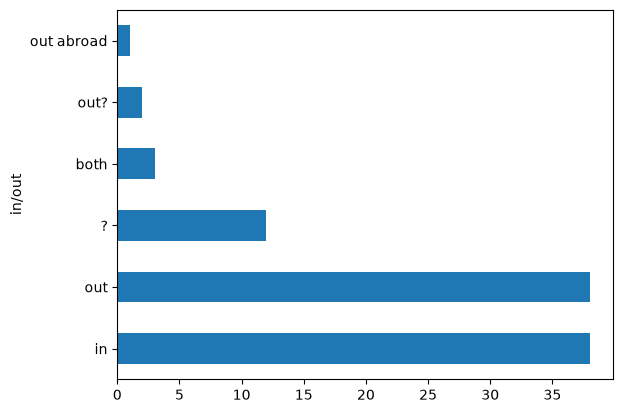

In [5]:
moving_record_formats["in/out"].value_counts().plot.barh()

In [6]:
moving_record_formats["side"] = moving_record_formats["sarakkeiden lkm"].str.extract(r'([a-zA-Z]*)')
moving_record_formats = moving_record_formats.drop(["pages", "sarakkeiden lkm"], axis=1)
moving_record_formats = moving_record_formats.rename({
    "print type": "print_type",
}, axis="columns")

### Non-ambiguous moving records

In [7]:
in_out_print_types = moving_record_formats[moving_record_formats["in/out"].isin(("in", "out"))]
in_out_print_types.loc[in_out_print_types["side"] == "", "side"] = "both"

In [8]:
in_out_print_types.loc[in_out_print_types.groupby(by=["print_type", "in/out"])["side"].transform("nunique") == 2, "side"] = "both"
in_out_print_types = in_out_print_types.drop_duplicates(subset=["print_type", "in/out"])

In [9]:
parish_books_formats = parish_books_formats[parish_books_formats["doc"] == "muuttaneet"]
parish_books_formats = parish_books_formats.rename(
    {
        "parish_normalized": "parishN",
        "Start_year": "year_start",
        "End_year": "year_end",
        "Source_type": "source_type",
        "Luokittelu": "print_type",
    }, axis="columns"
)
parish_books_formats = parish_books_formats[[
    "parish_id", "parish", "parishN",
    "year_start", "year_end",
    "source", "source_type",
    "url", "print_type",
]]

parish_books_formats = parish_books_formats.dropna()

In [10]:
def url_to_id(url):
    return int(url.split("=")[-1])

In [11]:
parish_books_formats["book_id"] = parish_books_formats["url"].map(url_to_id)
parish_books_formats = parish_books_formats.drop("url", axis="columns")
parish_books_formats["source"] = parish_books_formats["source"].str.lower()
parish_books_formats["print_type"] = parish_books_formats["print_type"].str.lower()

parish_books_formats[["parish_id", "year_start", "year_end"]] = (
    parish_books_formats[["parish_id", "year_start", "year_end"]].astype(
        "int32"
    )
)

### All moving records

In [13]:
moving_record_formats.loc[moving_record_formats["side"] == "", "side"] = "both"
moving_record_formats.loc[moving_record_formats.groupby(by=["print_type", "in/out"])["side"].transform("nunique") == 2, "side"] = "both"
moving_record_formats = moving_record_formats.drop_duplicates(subset=["print_type", "in/out"])

### Handling some of the more ambiguous print types

In [16]:
moving_record_formats.reset_index(inplace=True, drop=True)

moving_record_formats.loc[len(moving_record_formats)] = ["handrawn in/out", "in", "left"]
moving_record_formats.loc[len(moving_record_formats)] = ["handrawn out/in", "in", "right"]
moving_record_formats.loc[len(moving_record_formats)] = ["handrawn in", "in", "both"]
moving_record_formats.loc[len(moving_record_formats)] = ["free text in/out", "in", "left"]
moving_record_formats.loc[len(moving_record_formats)] = ["free text out/in", "in", "right"]
moving_record_formats.loc[len(moving_record_formats)] = ["free text in", "in", "both"]

moving_record_formats.loc[len(moving_record_formats)] = ["handrawn in/out", "out", "right"]
moving_record_formats.loc[len(moving_record_formats)] = ["handrawn out/in", "out", "left"]
moving_record_formats.loc[len(moving_record_formats)] = ["handrawn out", "out", "both"]
moving_record_formats.loc[len(moving_record_formats)] = ["free text in/out", "out", "right"]
moving_record_formats.loc[len(moving_record_formats)] = ["free text out/in", "out", "left"]
moving_record_formats.loc[len(moving_record_formats)] = ["free text out", "out", "both"]

### Books of immigrations and emigrations

In [18]:
csv_data_directory = "data/migration-data-csv-release-v1"
def books_to_paths(df):
    start_year = df["year_start"]
    end_year = df["year_end"]
    source = df["source"].lower()

    paths = list(Path(csv_data_directory).glob(
        f"*{df["parishN"]}/*{start_year}-{end_year}_{source}"
    ))

    if len(paths) == 0:
        return None
    else:
        return paths[0]

In [19]:
parish_books_formats["path"] = parish_books_formats.apply(books_to_paths, axis=1)
parish_books_formats.loc[~parish_books_formats["print_type"].isin(moving_record_formats["print_type"]), "print_type"] = "other"

In [20]:
book_migration_direction_info = parish_books_formats.merge(moving_record_formats, how="left")[["parish_id", "book_id", "print_type", "in/out", "side", "path"]]
book_migration_direction_info["in/out"] = book_migration_direction_info["in/out"].fillna("?")
book_migration_direction_info["side"] = book_migration_direction_info["side"].fillna("both")

In [22]:
book_migration_direction_info.to_csv("outputs/csv/book_migration_direction_info.csv", index=False)

### Coverage of data with known direction

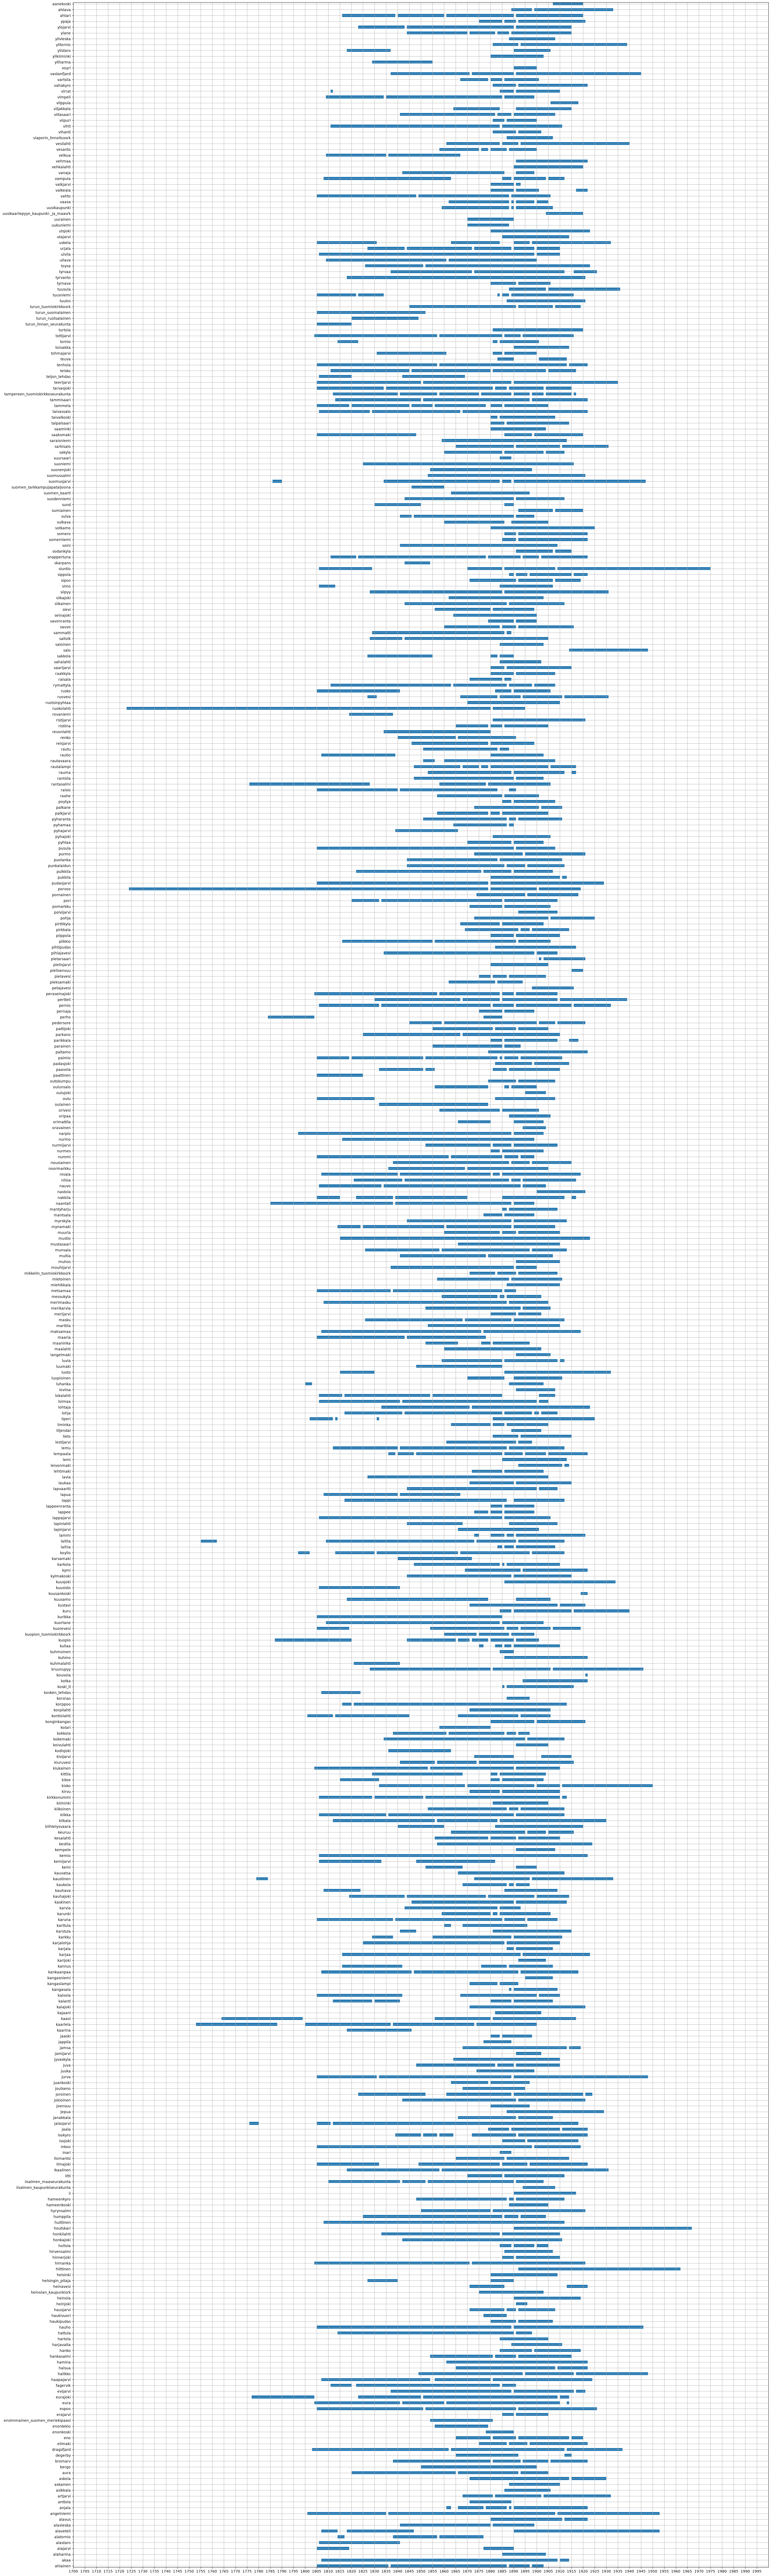

In [54]:
fig, ax = plt.subplots(figsize=(30, 100))
ax.set_xlim(1700, 2000)
ax.set_xticks(range(1700, 2000, 5))

for book_id in book_migration_direction_info[book_migration_direction_info["in/out"].isin(("in", "out"))]["book_id"].to_list():
    book = parish_books_formats[parish_books_formats["book_id"] == book_id].to_dict(orient="records")[0]
    ax.broken_barh(
        ((book["year_start"], book["year_end"] - book["year_start"]),), (book["parishN"], 0.5), align="center"
    )

ax.grid(True)
ax.margins(0)
fig.tight_layout()